# Experimento 5 — Opcionais 6.1 (arquiteturas) e 6.2 (regularização)
## Referências (já medidas em experimentos anteriores)

## 1. Setup

In [1]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [2]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 43


## 2. Hiperparâmetros e dataloaders comuns

In [3]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS_DEFAULT = 20

train_loader, val_loader, test_loader = get_dataloaders(
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

print(f"Treino:    {len(train_loader.dataset):>6d} amostras")
print(f"Validação: {len(val_loader.dataset):>6d} amostras")
print(f"Teste:     {len(test_loader.dataset):>6d} amostras")

Treino:     21312 amostras
Validação:   5328 amostras
Teste:      12630 amostras


### 2.1 Pesos por classe

In [4]:
def get_train_class_counts(loader, num_classes):
    subset = loader.dataset
    samples = subset.dataset._samples
    labels = np.array([samples[i][1] for i in subset.indices])
    return np.bincount(labels, minlength=num_classes)

TRAIN_COUNTS = get_train_class_counts(train_loader, NUM_CLASSES)
class_weights_np = TRAIN_COUNTS.sum() / (NUM_CLASSES * TRAIN_COUNTS.clip(min=1))
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

print(f"Pesos: min={class_weights_np.min():.3f}  max={class_weights_np.max():.3f}  median={np.median(class_weights_np):.3f}")

Pesos: min=0.412  max=4.165  median=1.471


## 3. Definição dos modelos
### 3.1 BN-CNN (referência) — com dropout configurável

In [ ]:
class BNCNN(nn.Module):
    def __init__(self, num_classes=43, img_size=32, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        spatial = img_size // 4
        fc_layers = [
            nn.Flatten(),
            nn.Linear(64 * spatial * spatial, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(256, num_classes))
        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        return self.classifier(self.features(x))

### 3.2 VGG-like pequena

In [6]:
class VGGLike(nn.Module):
    def __init__(self, num_classes=43, img_size=32, dropout=0.0):
        super().__init__()

        def conv_block(in_ch, out_ch, n_convs=2):
            layers = []
            for i in range(n_convs):
                layers += [
                    nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                ]
            layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.block1 = conv_block(3, 32, n_convs=2)
        self.block2 = conv_block(32, 64, n_convs=2)
        self.block3 = conv_block(64, 128, n_convs=1)

        spatial = img_size // 8
        fc_layers = [
            nn.Flatten(),
            nn.Linear(128 * spatial * spatial, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(256, num_classes))
        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

### 3.3 ResNet pequena

In [ ]:
class BasicBlock(nn.Module):

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out, inplace=True)

class ResNetSmall(nn.Module):
    def __init__(self, num_classes=43, blocks_per_stage=(2, 2, 2), dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.stage1 = self._make_stage(16, 16,  blocks_per_stage[0], stride=1)
        self.stage2 = self._make_stage(16, 32,  blocks_per_stage[1], stride=2)
        self.stage3 = self._make_stage(32, 64,  blocks_per_stage[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(64, num_classes)

    def _make_stage(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride=stride)]
        for _ in range(n_blocks - 1):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.avgpool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

### 3.4 Conferência de tamanho

In [ ]:
for name, ctor in (("BN-CNN (ref Exp 2)", lambda: BNCNN()),
                   ("VGG-like",            lambda: VGGLike()),
                   ("ResNet pequena",      lambda: ResNetSmall())):
    set_all_seeds(SEED)
    m = ctor()
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {name:<22s} : {n_params:,} parâmetros")
    del m

  BN-CNN (ref Exp 2)     : 1,079,979 parâmetros
  VGG-like               : 676,171 parâmetros
  ResNet pequena         : 177,403 parâmetros


## 4. Funções de treino, avaliação e métricas

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

## 5. Função de experimento unificada (com suporte a early stopping)

In [ ]:
def run_experiment(tag, model_ctor, *, use_weighted_loss=False,
                   weight_decay=0.0, num_epochs=NUM_EPOCHS_DEFAULT,
                   early_stopping_patience=None):

    print(f"\n{'=' * 78}")
    print(f"  Treinando: {tag}")
    es_msg = f"ES(patience={early_stopping_patience})" if early_stopping_patience else "ES(off)"
    print(f"    weighted_loss={use_weighted_loss}  weight_decay={weight_decay}  "
          f"max_epochs={num_epochs}  {es_msg}")
    print(f"{'=' * 78}")

    set_all_seeds(SEED)
    model = model_ctor().to(DEVICE)

    if use_weighted_loss:
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_epoch = 0.0, 0
    epochs_since_improvement = 0
    ckpt_path = f"checkpoints/exp5_{tag}_best.pt"
    early_stopped = False

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_since_improvement = 0
            torch.save(model.state_dict(), ckpt_path)
            flag = "  <-- melhor val_acc"
        else:
            epochs_since_improvement += 1

        print(f"  Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")

        if early_stopping_patience is not None and epochs_since_improvement >= early_stopping_patience:
            print(f"\n  >> Early stopping: {epochs_since_improvement} épocas sem melhoria "
                  f"(patience={early_stopping_patience})")
            early_stopped = True
            break

    elapsed = time.time() - t0
    print(f"  Tempo: {elapsed:.1f}s ({elapsed/60:.1f} min) | "
          f"Melhor val_acc: {best_val_acc:.4f} (ep {best_epoch}) | "
          f"Épocas executadas: {len(history['train_loss'])}")

    return {
        "tag": tag,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
        "early_stopped": early_stopped,
        "epochs_run": len(history["train_loss"]),
        "_model_ctor": model_ctor, 
    }

## 6. PARTE A

In [11]:
arch_results = {}

arch_results["vgg_like"] = run_experiment(
    "vgg_like",
    model_ctor=lambda: VGGLike(num_classes=NUM_CLASSES, img_size=IMG_SIZE),
)


  Treinando: vgg_like
    weighted_loss=False  weight_decay=0.0  max_epochs=20  ES(off)
  Epoch 01/20 | train_loss=1.1481 acc=0.7274 | val_loss=0.1651 acc=0.9855  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.0755 acc=0.9954 | val_loss=0.0446 acc=0.9962  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.0219 acc=0.9997 | val_loss=0.0258 acc=0.9976  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.0115 acc=1.0000 | val_loss=0.0176 acc=0.9987  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.0076 acc=1.0000 | val_loss=0.0148 acc=0.9987
  Epoch 06/20 | train_loss=0.0057 acc=1.0000 | val_loss=0.0126 acc=0.9991  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0046 acc=1.0000 | val_loss=0.0111 acc=0.9991
  Epoch 08/20 | train_loss=0.0038 acc=1.0000 | val_loss=0.0103 acc=0.9992  <-- melhor val_acc
  Epoch 09/20 | train_loss=0.0032 acc=1.0000 | val_loss=0.0100 acc=0.9992
  Epoch 10/20 | train_loss=0.0028 acc=1.0000 | val_loss=0.0085 acc=0.9992
  Epoch 11/20 | train_loss=0.0025 acc=1.0000 | val_

In [12]:
arch_results["resnet_small"] = run_experiment(
    "resnet_small",
    model_ctor=lambda: ResNetSmall(num_classes=NUM_CLASSES),
)


  Treinando: resnet_small
    weighted_loss=False  weight_decay=0.0  max_epochs=20  ES(off)
  Epoch 01/20 | train_loss=2.7343 acc=0.2467 | val_loss=2.4790 acc=0.3174  <-- melhor val_acc
  Epoch 02/20 | train_loss=1.3530 acc=0.5934 | val_loss=0.9065 acc=0.7248  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.5517 acc=0.8551 | val_loss=0.7728 acc=0.7421  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.1974 acc=0.9654 | val_loss=0.1519 acc=0.9698  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.0814 acc=0.9911 | val_loss=0.0900 acc=0.9831  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0413 acc=0.9970 | val_loss=0.0570 acc=0.9906  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0206 acc=0.9994 | val_loss=0.0500 acc=0.9912  <-- melhor val_acc
  Epoch 08/20 | train_loss=0.0151 acc=0.9996 | val_loss=0.0279 acc=0.9953  <-- melhor val_acc
  Epoch 09/20 | train_loss=0.0099 acc=0.9999 | val_loss=0.0550 acc=0.9859
  Epoch 10/20 | train_loss=0.0088 acc=0.9999 | val_loss=0.0152 acc=0.9976  <-- me

## 7. PARTE B

In [13]:
reg_results = {}

reg_results["dropout_std"] = run_experiment(
    "dropout_std",
    model_ctor=lambda: BNCNN(dropout=0.5),
    use_weighted_loss=False,
    num_epochs=20,
)
reg_results["wd_std"] = run_experiment(
    "wd_std",
    model_ctor=lambda: BNCNN(),
    use_weighted_loss=False,
    weight_decay=1e-4,
    num_epochs=20,
)
reg_results["es_std"] = run_experiment(
    "es_std",
    model_ctor=lambda: BNCNN(),
    use_weighted_loss=False,
    num_epochs=50,
    early_stopping_patience=5,
)


  Treinando: dropout_std
    weighted_loss=False  weight_decay=0.0  max_epochs=20  ES(off)
  Epoch 01/20 | train_loss=1.3086 acc=0.6839 | val_loss=0.3356 acc=0.9520  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.2664 acc=0.9531 | val_loss=0.1304 acc=0.9814  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.1337 acc=0.9794 | val_loss=0.0699 acc=0.9921  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.0823 acc=0.9886 | val_loss=0.0677 acc=0.9902
  Epoch 05/20 | train_loss=0.0576 acc=0.9933 | val_loss=0.0398 acc=0.9946  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0425 acc=0.9950 | val_loss=0.0362 acc=0.9942
  Epoch 07/20 | train_loss=0.0339 acc=0.9962 | val_loss=0.0286 acc=0.9961  <-- melhor val_acc
  Epoch 08/20 | train_loss=0.0284 acc=0.9968 | val_loss=0.0288 acc=0.9953
  Epoch 09/20 | train_loss=0.0243 acc=0.9971 | val_loss=0.0247 acc=0.9949
  Epoch 10/20 | train_loss=0.0222 acc=0.9977 | val_loss=0.0194 acc=0.9962  <-- melhor val_acc
  Epoch 11/20 | train_loss=0.0166 acc=0.9990 | v

In [14]:
reg_results["dropout_w"] = run_experiment(
    "dropout_w",
    model_ctor=lambda: BNCNN(dropout=0.5),
    use_weighted_loss=True,
    num_epochs=20,
)
reg_results["wd_w"] = run_experiment(
    "wd_w",
    model_ctor=lambda: BNCNN(),
    use_weighted_loss=True,
    weight_decay=1e-4,
    num_epochs=20,
)
reg_results["es_w"] = run_experiment(
    "es_w",
    model_ctor=lambda: BNCNN(),
    use_weighted_loss=True,
    num_epochs=50,
    early_stopping_patience=5,
)


  Treinando: dropout_w
    weighted_loss=True  weight_decay=0.0  max_epochs=20  ES(off)
  Epoch 01/20 | train_loss=1.4424 acc=0.6073 | val_loss=0.3436 acc=0.9200  <-- melhor val_acc
  Epoch 02/20 | train_loss=0.2830 acc=0.9261 | val_loss=0.1221 acc=0.9739  <-- melhor val_acc
  Epoch 03/20 | train_loss=0.1343 acc=0.9691 | val_loss=0.0829 acc=0.9771  <-- melhor val_acc
  Epoch 04/20 | train_loss=0.0838 acc=0.9806 | val_loss=0.0497 acc=0.9927  <-- melhor val_acc
  Epoch 05/20 | train_loss=0.0587 acc=0.9880 | val_loss=0.0393 acc=0.9929  <-- melhor val_acc
  Epoch 06/20 | train_loss=0.0452 acc=0.9903 | val_loss=0.0308 acc=0.9951  <-- melhor val_acc
  Epoch 07/20 | train_loss=0.0347 acc=0.9926 | val_loss=0.0254 acc=0.9970  <-- melhor val_acc
  Epoch 08/20 | train_loss=0.0302 acc=0.9946 | val_loss=0.0233 acc=0.9946
  Epoch 09/20 | train_loss=0.0246 acc=0.9954 | val_loss=0.0200 acc=0.9944
  Epoch 10/20 | train_loss=0.0215 acc=0.9964 | val_loss=0.0150 acc=0.9961
  Epoch 11/20 | train_loss=0.01

In [ ]:
all_results = {**arch_results, **reg_results}
summary = {tag: {k: v for k, v in r.items() if k not in ("ckpt_path", "_model_ctor")}
           for tag, r in all_results.items()}
with open("checkpoints/exp5_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp5_summary.json")

Resumo salvo em checkpoints/exp5_summary.json


## 8. Avaliação no conjunto de teste

In [16]:
test_results = {}

for tag, r in all_results.items():
    model = r["_model_ctor"]().to(DEVICE)
    model.load_state_dict(torch.load(r["ckpt_path"], map_location=DEVICE))
    y_true, y_pred = predict_all(model, test_loader, DEVICE)
    assert y_pred.shape == (12630,)

    per_class_acc, _ = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
    test_results[tag] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "per_class_acc": per_class_acc,
        "global_acc": float((y_pred == y_true).mean()),
        "macro_acc": float(per_class_acc.mean()),
    }
    print(f"  {tag:<15s} | global={test_results[tag]['global_acc']:.4f} | "
          f"macro={test_results[tag]['macro_acc']:.4f}")

  vgg_like        | global=0.9660 | macro=0.9472
  resnet_small    | global=0.9599 | macro=0.9387
  dropout_std     | global=0.9516 | macro=0.9279
  wd_std          | global=0.9324 | macro=0.8966
  es_std          | global=0.9350 | macro=0.9005
  dropout_w       | global=0.9501 | macro=0.9293
  wd_w            | global=0.9319 | macro=0.8997
  es_w            | global=0.9279 | macro=0.8945


## 9. Resultados — Parte A (Arquiteturas)

In [ ]:
REF_BN = {"test_global": 0.9363, "test_macro": 0.8993, "val": 0.9974, "epochs": 20}

print(f"  {'Modelo':<25s} | {'val':>7s} | {'test glob':>9s} | {'test macro':>10s} | {'gap v→t':>8s} | {'épocas':>7s}")
print("-" * 95)
gap_ref = REF_BN["test_global"] - REF_BN["val"]
print(f"  {'BN-CNN (ref Exp 2)':<25s} | {REF_BN['val']:>7.4f} | "
      f"{REF_BN['test_global']:>9.4f} | {REF_BN['test_macro']:>10.4f} | "
      f"{gap_ref:>+8.4f} | {REF_BN['epochs']:>7d}")

for tag in ("vgg_like", "resnet_small"):
    r = all_results[tag]
    tr = test_results[tag]
    gap = tr["global_acc"] - r["best_val_acc"]
    print(f"  {tag:<25s} | {r['best_val_acc']:>7.4f} | {tr['global_acc']:>9.4f} | "
          f"{tr['macro_acc']:>10.4f} | {gap:>+8.4f} | {r['epochs_run']:>7d}")

  Modelo                    |     val | test glob | test macro |  gap v→t |  épocas
-----------------------------------------------------------------------------------------------
  BN-CNN (ref Exp 2)        |  0.9974 |    0.9363 |     0.8993 |  -0.0611 |      20
  vgg_like                  |  0.9994 |    0.9660 |     0.9472 |  -0.0335 |      20
  resnet_small              |  0.9983 |    0.9599 |     0.9387 |  -0.0385 |      20


### 9.1 Ablação Parte A — Δ vs BN-CNN

In [18]:
ref_g = REF_BN["test_global"]
ref_m = REF_BN["test_macro"]
print(f"  {'Modelo':<15s} | {'Δ global':>10s} | {'Δ macro':>10s}")
print("-" * 50)
for tag in ("vgg_like", "resnet_small"):
    tr = test_results[tag]
    print(f"  {tag:<15s} | {tr['global_acc']-ref_g:>+10.4f} | {tr['macro_acc']-ref_m:>+10.4f}")

  Modelo          |   Δ global |    Δ macro
--------------------------------------------------
  vgg_like        |    +0.0297 |    +0.0479
  resnet_small    |    +0.0236 |    +0.0394


## 10. Resultados — Parte B (Regularização)

In [19]:
REF_WEIGHTED = {"test_global": 0.9335, "test_macro": 0.9013, "val": 0.9972, "epochs": 20}

print(f"  {'Modelo':<35s} | {'val':>7s} | {'test glob':>9s} | {'test macro':>10s} | {'gap v→t':>8s} | {'épocas':>7s}")
print("-" * 105)
print(f"  {'BN-CNN std CE (ref Exp 2)':<35s} | {REF_BN['val']:>7.4f} | "
      f"{REF_BN['test_global']:>9.4f} | {REF_BN['test_macro']:>10.4f} | "
      f"{REF_BN['test_global']-REF_BN['val']:>+8.4f} | {REF_BN['epochs']:>7d}")
print(f"  {'BN-CNN weighted CE (ref Exp 4)':<35s} | {REF_WEIGHTED['val']:>7.4f} | "
      f"{REF_WEIGHTED['test_global']:>9.4f} | {REF_WEIGHTED['test_macro']:>10.4f} | "
      f"{REF_WEIGHTED['test_global']-REF_WEIGHTED['val']:>+8.4f} | {REF_WEIGHTED['epochs']:>7d}")
print("-" * 105)
for tag in ("dropout_std", "wd_std", "es_std", "dropout_w", "wd_w", "es_w"):
    r = all_results[tag]
    tr = test_results[tag]
    gap = tr["global_acc"] - r["best_val_acc"]
    desc = "+" + tag.replace("_std", " + std CE").replace("_w", " + weighted CE")
    desc = desc.replace("+dropout", "dropout(0.5)").replace("+wd", "weight_decay(1e-4)")\
               .replace("+es", "early_stopping(p=5)")
    print(f"  {desc:<35s} | {r['best_val_acc']:>7.4f} | {tr['global_acc']:>9.4f} | "
          f"{tr['macro_acc']:>10.4f} | {gap:>+8.4f} | {r['epochs_run']:>7d}")

  Modelo                              |     val | test glob | test macro |  gap v→t |  épocas
---------------------------------------------------------------------------------------------------------
  BN-CNN std CE (ref Exp 2)           |  0.9974 |    0.9363 |     0.8993 |  -0.0611 |      20
  BN-CNN weighted CE (ref Exp 4)      |  0.9972 |    0.9335 |     0.9013 |  -0.0637 |      20
---------------------------------------------------------------------------------------------------------
  dropout(0.5) + std CE               |  0.9974 |    0.9516 |     0.9279 |  -0.0457 |      20
  weight_decay(1e-4) + std CE         |  0.9974 |    0.9324 |     0.8966 |  -0.0650 |      20
  early_stopping(p=5) + std CE        |  0.9974 |    0.9350 |     0.9005 |  -0.0624 |      23
  dropout(0.5) + weighted CE          |  0.9972 |    0.9501 |     0.9293 |  -0.0471 |      20
  weight_decay(1e-4) + weighted CE    |  0.9972 |    0.9319 |     0.8997 |  -0.0653 |      20
  early_stopping(p=5) + weighted CE 

### 10.1 Ablação Parte B — Δ vs base apropriada

In [20]:
print(f"  {'Modelo':<25s} | {'base':<10s} | {'Δ global':>10s} | {'Δ macro':>10s} | {'Δ gap v→t':>11s}")
print("-" * 80)
for tag in ("dropout_std", "wd_std", "es_std", "dropout_w", "wd_w", "es_w"):
    tr = test_results[tag]
    r = all_results[tag]
    if tag.endswith("_std"):
        base_g, base_m, base_val = REF_BN["test_global"], REF_BN["test_macro"], REF_BN["val"]
        base_label = "std CE"
    else:
        base_g, base_m, base_val = REF_WEIGHTED["test_global"], REF_WEIGHTED["test_macro"], REF_WEIGHTED["val"]
        base_label = "weighted CE"
    d_g = tr["global_acc"] - base_g
    d_m = tr["macro_acc"] - base_m
    base_gap = base_g - base_val
    this_gap = tr["global_acc"] - r["best_val_acc"]
    d_gap = this_gap - base_gap
    print(f"  {tag:<25s} | {base_label:<10s} | {d_g:>+10.4f} | {d_m:>+10.4f} | {d_gap:>+11.4f}")

  Modelo                    | base       |   Δ global |    Δ macro |   Δ gap v→t
--------------------------------------------------------------------------------
  dropout_std               | std CE     |    +0.0153 |    +0.0286 |     +0.0154
  wd_std                    | std CE     |    -0.0039 |    -0.0027 |     -0.0039
  es_std                    | std CE     |    -0.0013 |    +0.0012 |     -0.0013
  dropout_w                 | weighted CE |    +0.0166 |    +0.0280 |     +0.0166
  wd_w                      | weighted CE |    -0.0016 |    -0.0016 |     -0.0016
  es_w                      | weighted CE |    -0.0056 |    -0.0068 |     -0.0051


## 11. As 5 classes difíceis do baseline

In [21]:
HARD_CLASSES = [0, 30, 27, 24, 21]
HEADERS = ("vgg_like", "resnet_small",
           "dropout_std", "wd_std", "es_std",
           "dropout_w", "wd_w", "es_w")

print("  cls | " + " | ".join(f"{t:>13s}" for t in HEADERS))
print("-" * (8 + 16 * len(HEADERS)))
for c in HARD_CLASSES:
    row = f"  {c:>3d}  | "
    row += " | ".join(f"{test_results[t]['per_class_acc'][c]:>13.4f}" for t in HEADERS)
    print(row + f"  ({GTSRB_CLASSES[c]})")

print()
print("  Média sobre as 5 classes difíceis:")
print(f"    ref Exp 2 (BN+SGDmom, std CE)        = 0.6213")
print(f"    ref Exp 4 (BN+SGDmom, weighted CE)   = 0.6492  (val=0.9972)")
for t in HEADERS:
    m = float(np.mean([test_results[t]["per_class_acc"][c] for c in HARD_CLASSES]))
    print(f"    {t:<35s}  = {m:.4f}")

  cls |      vgg_like |  resnet_small |   dropout_std |        wd_std |        es_std |     dropout_w |          wd_w |          es_w
----------------------------------------------------------------------------------------------------------------------------------------
    0  |        0.8667 |        1.0000 |        0.7167 |        0.5333 |        0.5833 |        0.6833 |        0.6000 |        0.5500  (Speed limit (20km/h))
   30  |        0.6533 |        0.7267 |        0.6200 |        0.5000 |        0.5533 |        0.7733 |        0.5400 |        0.4667  (Beware of ice/snow)
   27  |        0.8833 |        0.5667 |        0.8333 |        0.5167 |        0.5500 |        0.5833 |        0.5167 |        0.5167  (Pedestrians)
   24  |        0.8778 |        0.9778 |        0.8444 |        0.7111 |        0.7889 |        0.7889 |        0.7667 |        0.7889  (Road narrows right)
   21  |        0.6444 |        0.6556 |        0.8667 |        0.8333 |        0.8222 |        0.8111 |  

## 12. Acurácia por classe

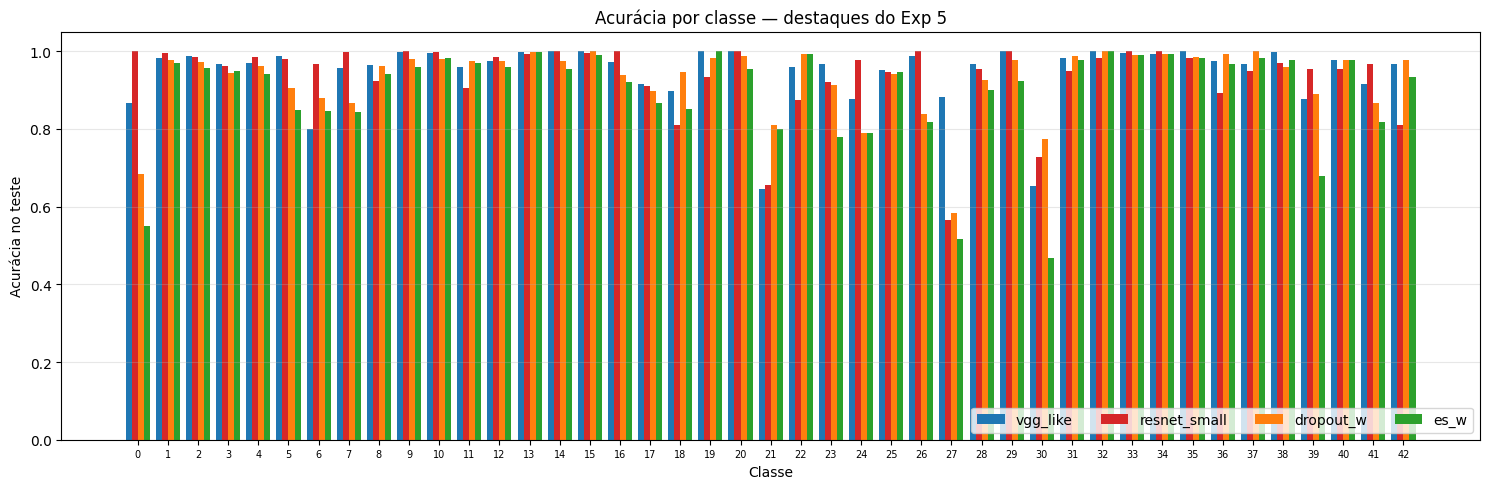

In [22]:
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(NUM_CLASSES)
tags_to_plot = ("vgg_like", "resnet_small", "dropout_w", "es_w")
colors = ("tab:blue", "tab:red", "tab:orange", "tab:green")
width = 0.20
for i, (tag, color) in enumerate(zip(tags_to_plot, colors)):
    ax.bar(x + (i - 1.5) * width, test_results[tag]["per_class_acc"], width,
           label=tag, color=color)
ax.set_xlabel("Classe"); ax.set_ylabel("Acurácia no teste")
ax.set_title("Acurácia por classe — destaques do Exp 5")
ax.set_xticks(x); ax.set_xticklabels(x, fontsize=7)
ax.set_ylim(0, 1.05); ax.legend(loc="lower right", ncol=4)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/exp5_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Salvar predições

In [23]:
for tag, tr in test_results.items():
    out_path = f"results/predicoes_exp5_{tag}.csv"
    save_predictions(tr["y_pred"], out_path, experiment_name=f"Exp5 {tag} | img=32")
    print(f"  {out_path}")

  results/predicoes_exp5_vgg_like.csv
  results/predicoes_exp5_resnet_small.csv
  results/predicoes_exp5_dropout_std.csv
  results/predicoes_exp5_wd_std.csv
  results/predicoes_exp5_es_std.csv
  results/predicoes_exp5_dropout_w.csv
  results/predicoes_exp5_wd_w.csv
  results/predicoes_exp5_es_w.csv


## 14. Eleição final do modelo

In [24]:
candidates = [
    {"name": "ref_exp2 BN+SGDmom std CE",
     "global": REF_BN["test_global"], "macro": REF_BN["test_macro"],
     "csv": "results/predicoes_exp2_BN_conv_fc__sgd_mom.csv"},
    {"name": "ref_exp4 BN+SGDmom weighted CE",
     "global": REF_WEIGHTED["test_global"], "macro": REF_WEIGHTED["test_macro"],
     "csv": "results/predicoes_exp4_weighted.csv"},
]
for tag, tr in test_results.items():
    candidates.append({
        "name": f"exp5_{tag}",
        "global": tr["global_acc"],
        "macro": tr["macro_acc"],
        "csv": f"results/predicoes_exp5_{tag}.csv",
    })

best_global = max(candidates, key=lambda d: d["global"])
best_macro  = max(candidates, key=lambda d: d["macro"])

print("Top 5 por test GLOBAL:")
for d in sorted(candidates, key=lambda d: -d["global"])[:5]:
    print(f"  global={d['global']:.4f}  macro={d['macro']:.4f}  ← {d['name']}")

print("\nTop 5 por test MACRO:")
for d in sorted(candidates, key=lambda d: -d["macro"])[:5]:
    print(f"  macro={d['macro']:.4f}  global={d['global']:.4f}  ← {d['name']}")

print(f"\nMelhor por GLOBAL: {best_global['name']}  →  {best_global['csv']}")
print(f"Melhor por MACRO:  {best_macro['name']}  →  {best_macro['csv']}")

Top 5 por test GLOBAL:
  global=0.9660  macro=0.9472  ← exp5_vgg_like
  global=0.9599  macro=0.9387  ← exp5_resnet_small
  global=0.9516  macro=0.9279  ← exp5_dropout_std
  global=0.9501  macro=0.9293  ← exp5_dropout_w
  global=0.9363  macro=0.8993  ← ref_exp2 BN+SGDmom std CE

Top 5 por test MACRO:
  macro=0.9472  global=0.9660  ← exp5_vgg_like
  macro=0.9387  global=0.9599  ← exp5_resnet_small
  macro=0.9293  global=0.9501  ← exp5_dropout_w
  macro=0.9279  global=0.9516  ← exp5_dropout_std
  macro=0.9013  global=0.9335  ← ref_exp4 BN+SGDmom weighted CE

Melhor por GLOBAL: exp5_vgg_like  →  results/predicoes_exp5_vgg_like.csv
Melhor por MACRO:  exp5_vgg_like  →  results/predicoes_exp5_vgg_like.csv


### 14.1 Geração do CSV de entrega

In [ ]:
import shutil

USE_CRITERION = "macro" 
NAMES = "MATHEUS_"  

chosen = best_global if USE_CRITERION == "global" else best_macro
print(f"Critério: {USE_CRITERION}")
print(f"Modelo escolhido: {chosen['name']}")
print(f"  global = {chosen['global']:.4f}")
print(f"  macro  = {chosen['macro']:.4f}")

final_path = f"results/{NAMES}_RESULTS.csv"

src = Path(chosen["csv"])
if not src.exists():
    print(f"\n⚠️  Arquivo fonte não encontrado: {src}")
else:
    shutil.copy(src, final_path)
    print(f"\n✓ Arquivo de entrega: {final_path}")

Critério: macro
Modelo escolhido: exp5_vgg_like
  global = 0.9660
  macro  = 0.9472

✓ Arquivo de entrega: results/MATHEUS_NOME2_RESULTS.csv
